# Predicting eddy tilt magnitude and direction from surface information

This workflow answers two different questions for **AE and CE separately**:

1. Can surface structure and environmental variables predict tilt in an unseen eddy?
2. Which feature groups have stable descriptive or predictive associations with tilt?

Tilt magnitude and circular direction are modelled separately. Model family and feature-set selection occur inside every outer eddy-grouped fold, so no repeatedly inspected final set is called untouched. Spatially blocked validation is added as a stress test. Feature ablation and beta-association results are evidence of association, not causality.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seacofs_tilt_tools as tilt
import ml_subsurface_tools as ml

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
OUTER_FOLDS = 5
INNER_FOLDS = 3
DIRECTION_MIN_TILT_KM = 5.0
GRID_ROTATION_DEG = 20.0

# Restrict the nested search to interpretable group comparisons. More
# detailed alternatives are assessed later as descriptive sensitivity tests.
NESTED_FEATURE_SETS = {
    name: ml.FEATURE_SETS[name]
    for name in ["full", "without_PV", "without_propagation",
                 "without_beta", "structure_environment", "beta_only"]
}

## 1. Load a common, fully observed vertical interval

Tilt is capped near 859 m, so only eddy-days whose vertical profile extends beyond 850 m are retained. PV-gradient terms must be based only on information that would be available at prediction time; verify that `add_pv_gradient_terms(..., core_mean=True)` does not use the subsurface tilt target or future information.

In [2]:
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths)
df_vert = tilt.load_vert(paths)

max_depth = (
    df_vert.groupby(["Eddy", "Day"], as_index=False)["Depth"]
    .max().rename(columns={"Depth": "max_profile_depth"})
)
df_eddies = df_eddies.merge(max_depth, on=["Eddy", "Day"], how="inner")
df_eddies = df_eddies[df_eddies["max_profile_depth"] > 850].copy()
df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=True)
display(ml.target_availability_summary(df_eddies))

,rows,valid_tilt_rows,valid_fraction,eddies,eddies_with_tilt
group,,,,,
All,88199,79390,0.900124,2793,2745
AE,42658,38935,0.912724,1319,1284
CE,45541,40455,0.888320,1474,1461


## 2. Engineer non-redundant predictors

The model uses `Rc` and `Omega` for surface structure; beta and bathymetry for environment; propagation; geographic ellipse orientation; and PV-gradient magnitude plus **unit direction components**. Raw PV east/north components are retained only for diagnostics because including them together with magnitude duplicates information.

`norm_time` is excluded because normalising by an eddy's final lifetime uses future knowledge. Propagation requires the previous observed position and therefore belongs to a trajectory-enabled prediction task, not a single-image task. The ellipse q-matrix is rotated +20 degrees from the model grid into geographic coordinates (equivalent to +40 degrees in doubled-angle space).

In [3]:
model_df = ml.prepare_modelling_table(df_eddies, grid_rotation_deg=GRID_ROTATION_DEG)
polarity_data = {cyc: model_df[model_df["Cyc"] == cyc].copy() for cyc in ("AE", "CE")}

display(pd.Series(ml.FEATURES, name="model_feature").to_frame())
display(pd.DataFrame({
    cyc: {"rows": len(part), "eddies": part["Eddy"].nunique()}
    for cyc, part in polarity_data.items()
}).T)

ellipse_norm = np.sqrt(model_df["ellipse_major_sin2"] ** 2 + model_df["ellipse_major_cos2"] ** 2)
display(ellipse_norm.describe().rename("ellipse_encoding_norm"))

,model_feature
0,Rc
1,Omega
2,beta
3,h
4,prop_east_km_day
5,prop_north_km_day
6,ellipse_major_cos2
7,ellipse_major_sin2
8,PV_grad_mag
9,PV_grad_unit_east


,rows,eddies
AE,38935,1284
CE,40455,1461


count    7.939000e+04
mean     1.000000e+00
std      1.196771e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: ellipse_encoding_norm, dtype: float64

### Direct descriptive test of the polarity-specific PV hypothesis

For CE, the expected bearing is the raw PV gradient. For AE, it is the opposite bearing. This table tests the hypothesis directly before ML; it should not be inferred from model importance.

In [4]:
hypothesis = []
for cyc, part in polarity_data.items():
    raw = ml.angular_error_deg(part["TiltDir"], part["PV_grad_theta"])
    expected = ml.angular_error_deg(part["TiltDir"], part["PV_reference_theta"])
    hypothesis.append({
        "Cyc": cyc, "median_error_raw_PV_deg": np.median(raw),
        "within_30deg_raw_PV": np.mean(raw <= 30),
        "median_error_expected_deg": np.median(expected),
        "within_30deg_expected": np.mean(expected <= 30),
    })
display(pd.DataFrame(hypothesis).set_index("Cyc").round(3))

,median_error_raw_PV_deg,within_30deg_raw_PV,median_error_expected_deg,within_30deg_expected
Cyc,,,,
AE,95.604,0.141,84.396,0.179
CE,64.149,0.259,64.149,0.259


## 3. Nested eddy-grouped prediction

Every outer fold holds out complete eddies. Within the remaining eddies, inner grouped CV selects Ridge versus restrained gradient boosting and selects a feature group. Thus each outer score represents a model-development process applied to unseen eddies. Each eddy receives equal total training weight.

Magnitude is modelled as `log1p(TiltDis)` and transformed back to kilometres. Direction is modelled as unit east/north components and is trained only where tilt is at least 5 km. This section is computationally intensive.

In [5]:
nested = {}
for cyc, part in polarity_data.items():
    nested[cyc] = {}
    for task in ("magnitude", "direction"):
        task_data = part if task == "magnitude" else part[part["TiltDis"] >= DIRECTION_MIN_TILT_KM].copy()
        print(f"Nested CV: {cyc} {task} ({task_data['Eddy'].nunique()} eddies)")
        scores, selections, predictions = ml.nested_grouped_evaluation(
            task_data, task, feature_sets=NESTED_FEATURE_SETS,
            outer_splits=OUTER_FOLDS, inner_splits=INNER_FOLDS,
            minimum_tilt_km=DIRECTION_MIN_TILT_KM, random_state=RANDOM_STATE,
        )
        nested[cyc][task] = {"scores": scores, "selections": selections, "predictions": predictions}
        display(ml.summarise_outer_scores(scores, task).round(3))
        display(selections)

Nested CV: AE magnitude (1284 eddies)


,mean_score,fold_SD,secondary_mean
model,,,
Selected model,15.269,0.671,0.160
Eddy-median baseline,16.627,0.580,-0.005


,outer_fold,family,params_key,feature_set,inner_score
0,1,Ridge,ridge_100,full,15.340861
1,2,Gradient boosting,boost_15,full,15.084089
2,3,Ridge,ridge_100,full,15.568878
3,4,Gradient boosting,boost_15,full,15.143069
4,5,Ridge,ridge_100,without_propagation,15.273908


Nested CV: AE direction (1279 eddies)


,mean_score,fold_SD,secondary_mean
model,,,
Selected model,63.434,1.721,0.382
Mean-direction baseline,71.304,3.432,0.294
Polarity-aligned PV baseline,89.804,2.899,0.177
Propagation-direction baseline,97.267,1.003,0.132


...

,mean_score,fold_SD,secondary_mean
model,,,
Selected model,11.399,0.291,0.189
Eddy-median baseline,13.092,0.302,-0.028


,outer_fold,family,params_key,feature_set,inner_score
0,1,Ridge,ridge_1,full,11.374485
1,2,Gradient boosting,boost_regularised,full,11.406572
2,3,Gradient boosting,boost_regularised,full,11.183135
3,4,Ridge,ridge_1,full,11.203353
4,5,Ridge,ridge_1,full,11.228991


Nested CV: CE direction (1459 eddies)


,mean_score,fold_SD,secondary_mean
model,,,
Selected model,60.960,2.075,0.381
Polarity-aligned PV baseline,75.990,1.603,0.265
Mean-direction baseline,76.699,2.249,0.281
Propagation-direction baseline,87.043,1.443,0.175


,outer_fold,family,params_key,feature_set,inner_score
0,1,Gradient boosting,boost_regularised,full,61.275283
1,2,Gradient boosting,boost_regularised,full,62.048767
2,3,Gradient boosting,boost_15,full,61.514669
3,4,Gradient boosting,boost_15,full,62.450529
4,5,Gradient boosting,boost_15,full,60.781404


## 4. Out-of-fold calibration and direction diagnostics

All plotted predictions come from outer folds in which the relevant eddy was unseen. Look for systematic underprediction of large magnitudes and report direction separately at 5, 10 and 20 km thresholds.

,rows,median_angular_error_deg,within_30deg_fraction
minimum_tilt_km,,,
5,35095,42.847,0.382
10,28240,40.152,0.402
20,16768,37.157,0.424


,rows,median_angular_error_deg,within_30deg_fraction
minimum_tilt_km,,,
5,35263,42.242,0.381
10,26399,39.902,0.399
20,13354,38.067,0.415


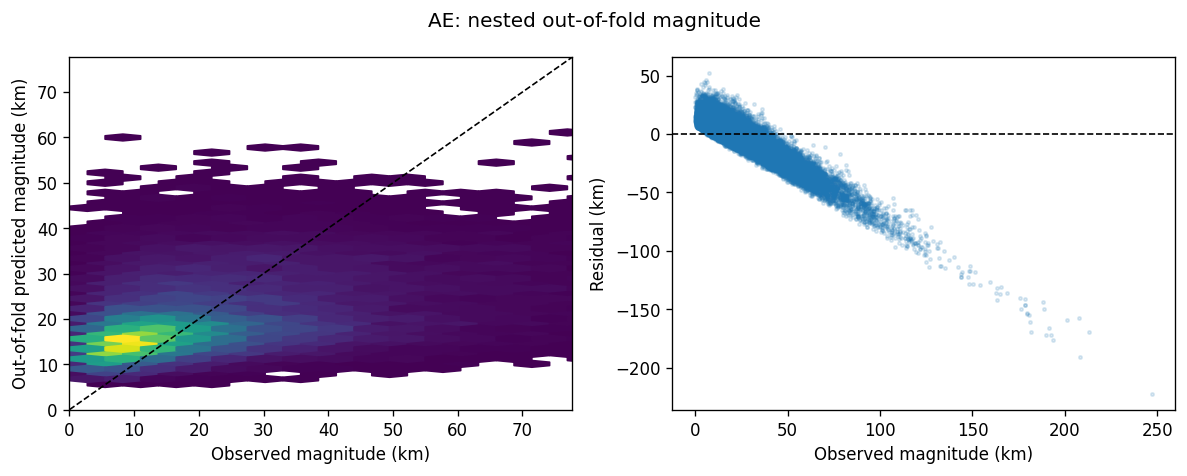

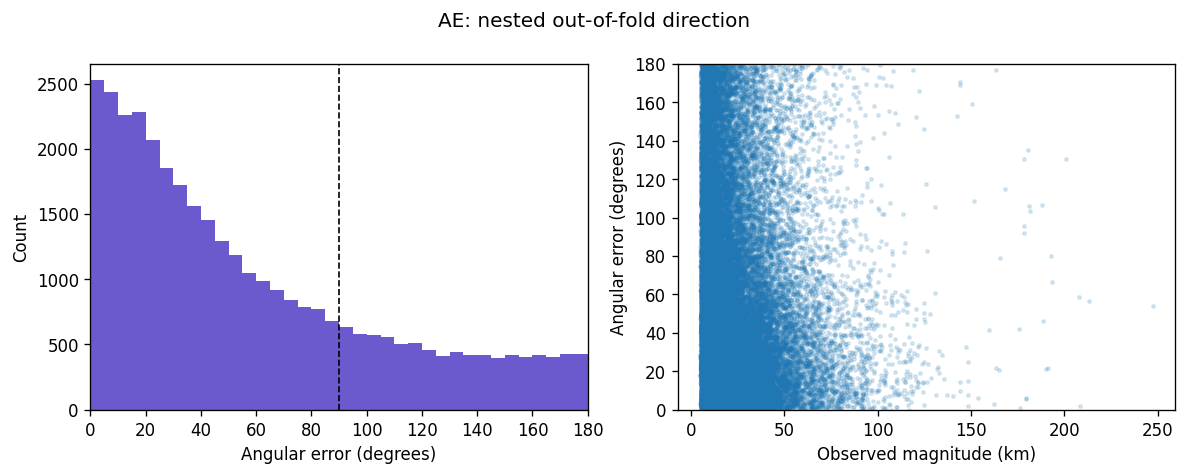

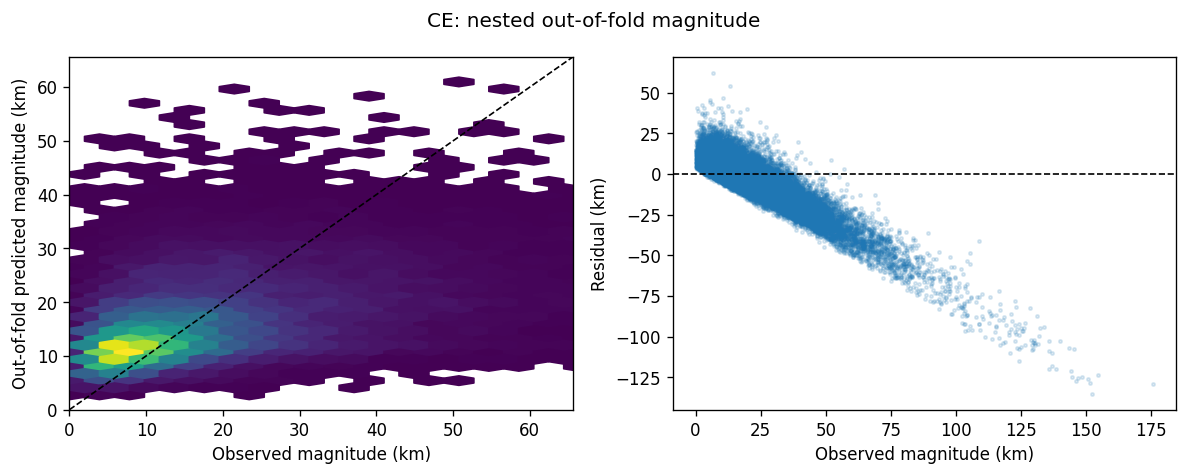

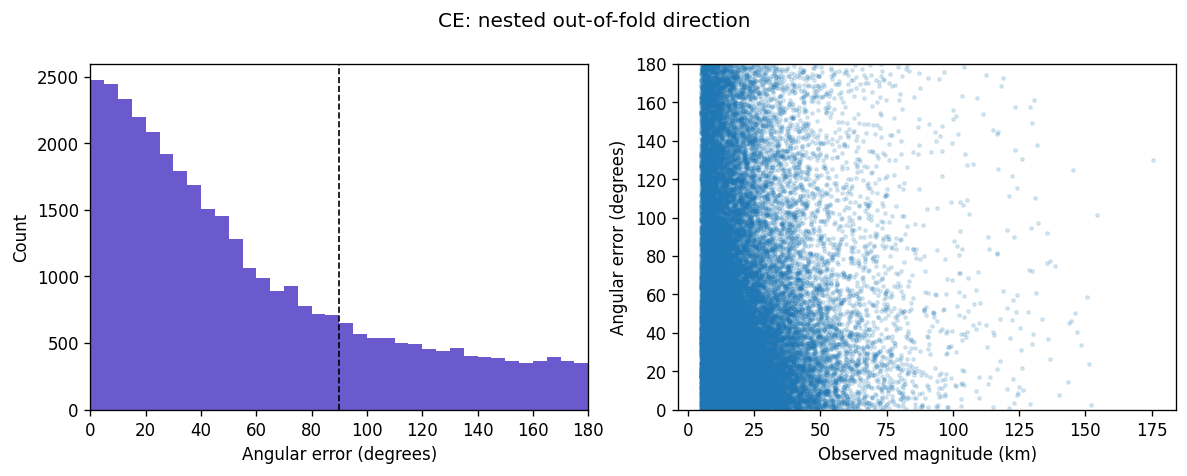

In [6]:
for cyc in ("AE", "CE"):
    magnitude_pred = nested[cyc]["magnitude"]["predictions"]
    direction_pred = nested[cyc]["direction"]["predictions"]
    ml.plot_magnitude_oof(magnitude_pred, title=f"{cyc}: nested out-of-fold magnitude")
    ml.plot_direction_oof(direction_pred, title=f"{cyc}: nested out-of-fold direction")
    display(ml.direction_performance_by_tilt(direction_pred, thresholds=(5, 10, 20)).round(3))

## 5. Full-data development sensitivity: feature groups

The nested outer results above are the unbiased prediction estimates. This section uses grouped CV on all available eddies to compare detailed feature removals. It is a development/association diagnostic, not a new test score. Differences should be compared with fold variability; tiny rank differences are not evidence that one representation is optimal.

In [7]:
development = {}
for cyc, part in polarity_data.items():
    development[cyc] = {}
    for task in ("magnitude", "direction"):
        task_data = part if task == "magnitude" else part[part["TiltDis"] >= DIRECTION_MIN_TILT_KM].copy()
        config, cv_results = ml.select_configuration_grouped(
            task_data, task, feature_sets=ml.FEATURE_SETS, n_splits=INNER_FOLDS, random_state=RANDOM_STATE
        )
        development[cyc][task] = {"config": config, "cv_results": cv_results}
        print(cyc, task, config)
        display(ml.feature_set_comparison(cv_results, task).round(3))

AE magnitude Configuration(family='Gradient boosting', params_key='boost_regularised', params={'learning_rate': 0.05, 'max_iter': 300, 'max_leaf_nodes': 15, 'min_samples_leaf': 125, 'l2_regularization': 10.0}, feature_set='without_PV_direction')


,feature_set,family,params_key,eddy_weighted_magnitude_MAE_km
17,without_PV_direction,Gradient boosting,boost_regularised,15.201
7,full,Ridge,ridge_100,15.260
35,without_propagation,Ridge,ridge_100,15.261
31,without_ellipse,Ridge,ridge_100,15.268
22,without_PV_magnitude,Ridge,ridge_1,15.277
13,without_PV,Gradient boosting,boost_regularised,15.291
10,structure_environment,Ridge,ridge_1,15.309
1,beta_only,Gradient boosting,boost_regularised,15.544
24,without_beta,Gradient boosting,boost_15,15.758


AE direction Configuration(family='Gradient boosting', params_key='boost_15', params={'learning_rate': 0.05, 'max_iter': 300, 'max_leaf_nodes': 15, 'min_samples_leaf': 75, 'l2_regularization': 1.0}, feature_set='full')


,feature_set,family,params_key,eddy_weighted_mean_angular_error_deg
4,full,Gradient boosting,boost_15,63.743
21,without_PV_magnitude,Gradient boosting,boost_regularised,63.835
16,without_PV_direction,Gradient boosting,boost_15,64.141
12,without_PV,Gradient boosting,boost_15,64.210
29,without_ellipse,Gradient boosting,boost_regularised,64.496
24,without_beta,Gradient boosting,boost_15,64.614
32,without_propagation,Gradient boosting,boost_15,68.950
10,structure_environment,Ridge,ridge_1,69.325
2,beta_only,Ridge,ridge_1,70.219


CE magnitude Configuration(family='Gradient boosting', params_key='boost_15', params={'learning_rate': 0.05, 'max_iter': 300, 'max_leaf_nodes': 15, 'min_samples_leaf': 75, 'l2_regularization': 1.0}, feature_set='full')


,feature_set,family,params_key,eddy_weighted_magnitude_MAE_km
4,full,Gradient boosting,boost_15,11.240
21,without_PV_magnitude,Gradient boosting,boost_regularised,11.247
29,without_ellipse,Gradient boosting,boost_regularised,11.289
17,without_PV_direction,Gradient boosting,boost_regularised,11.309
13,without_PV,Gradient boosting,boost_regularised,11.328
32,without_propagation,Gradient boosting,boost_15,11.389
9,structure_environment,Gradient boosting,boost_regularised,11.481
24,without_beta,Gradient boosting,boost_15,11.838
1,beta_only,Gradient boosting,boost_regularised,12.100


CE direction Configuration(family='Gradient boosting', params_key='boost_15', params={'learning_rate': 0.05, 'max_iter': 300, 'max_leaf_nodes': 15, 'min_samples_leaf': 75, 'l2_regularization': 1.0}, feature_set='full')


,feature_set,family,params_key,eddy_weighted_mean_angular_error_deg
4,full,Gradient boosting,boost_15,61.371
21,without_PV_magnitude,Gradient boosting,boost_regularised,61.695
25,without_beta,Gradient boosting,boost_regularised,61.821
29,without_ellipse,Gradient boosting,boost_regularised,62.039
17,without_PV_direction,Gradient boosting,boost_regularised,62.706
13,without_PV,Gradient boosting,boost_regularised,63.530
32,without_propagation,Gradient boosting,boost_15,66.994
8,structure_environment,Gradient boosting,boost_15,70.502
0,beta_only,Gradient boosting,boost_15,75.469


## 6. Companion beta–tilt-magnitude analysis

Permutation or ablation importance does not show the direction or shape of an association. Here each eddy contributes one median beta and one median tilt magnitude, avoiding thousands of daily rows being treated as independent. Spearman correlation and an eddy bootstrap confidence interval provide a transparent unadjusted association. The binned curve shows shape but is not causal; beta may still encode geography and covary with `Rc`, `Omega`, bathymetry or EAC regime.

,eddies,spearman_rho,CI_low,CI_high
Cyc,,,,
AE,1284,-0.400,-0.447,-0.350
CE,1461,-0.461,-0.502,-0.421


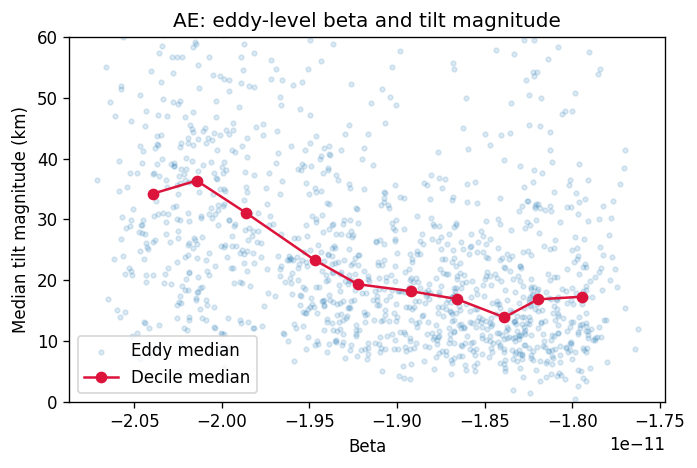

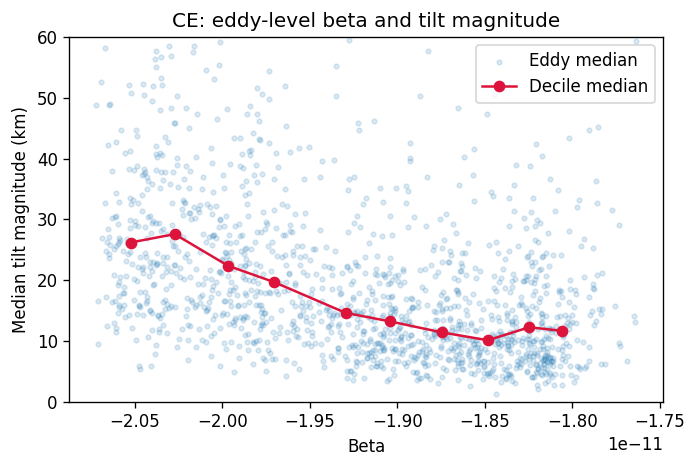

In [8]:
beta_results = []
for cyc, part in polarity_data.items():
    result, eddy_table = ml.beta_magnitude_association(part, n_boot=1000, random_state=RANDOM_STATE)
    beta_results.append({"Cyc": cyc, **result})
    ml.plot_beta_relationship(eddy_table, title=f"{cyc}: eddy-level beta and tilt magnitude", ylim=(0,60))
display(pd.DataFrame(beta_results).set_index("Cyc").round(3))

## 7. Propagation-confounding diagnostic

The EAC and coastline can impose a shared southwestward pathway. The table separates each eddy's full-track mean propagation from day-to-day anomalies around that mean. If track means associate with tilt but within-track anomalies do not, propagation is more likely acting as a pathway/regional proxy. Full-track means use future information and are **diagnostic only**, never predictive inputs.

In [9]:
for cyc, part in polarity_data.items():
    prop_summary, prop_diagnostic = ml.propagation_confounding_summary(part)
    print(cyc)
    display(prop_summary.round(3))

AE


,spearman_with_tilt_magnitude
quantity,
track_mean_prop_east,-0.051
track_mean_prop_north,0.012
prop_east_anomaly,-0.050
prop_north_anomaly,-0.028


CE


,spearman_with_tilt_magnitude
quantity,
track_mean_prop_east,-0.116
track_mean_prop_north,0.045
prop_east_anomaly,-0.031
prop_north_anomaly,-0.031


## 8. Spatial-block stress test

Random unseen eddies can occupy the same EAC pathway as training eddies. This stress test assigns each complete eddy to a block using its median track position and holds out blocks. It uses the consensus configuration from nested folds, rather than retuning against spatial-test blocks. A large deterioration suggests that beta, bathymetry, propagation or PV terms partly encode regional structure.

In [10]:
spatial_results = {}
for cyc, part in polarity_data.items():
    spatial_results[cyc] = {}
    for task in ("magnitude", "direction"):
        task_data = part if task == "magnitude" else part[part["TiltDis"] >= DIRECTION_MIN_TILT_KM].copy()
        config = ml.consensus_configuration(nested[cyc][task]["selections"])
        spatial = ml.spatial_block_evaluation(
            task_data, task, config, n_splits=4, minimum_tilt_km=DIRECTION_MIN_TILT_KM
        )
        spatial_results[cyc][task] = spatial
        metric = "eddy_weighted_magnitude_MAE_km" if task == "magnitude" else "eddy_weighted_mean_angular_error_deg"
        print(cyc, task, config)
        display(spatial[[metric]].agg(["mean", "std"]).round(3))

AE magnitude Configuration(family='Ridge', params_key='ridge_100', params={'alpha': 100.0}, feature_set='full')


,eddy_weighted_magnitude_MAE_km
mean,15.237
std,1.999


AE direction Configuration(family='Gradient boosting', params_key='boost_regularised', params={'learning_rate': 0.05, 'max_iter': 300, 'max_leaf_nodes': 15, 'min_samples_leaf': 125, 'l2_regularization': 10.0}, feature_set='full')


,eddy_weighted_mean_angular_error_deg
mean,66.517
std,3.219


CE magnitude Configuration(family='Ridge', params_key='ridge_1', params={'alpha': 1.0}, feature_set='full')


,eddy_weighted_magnitude_MAE_km
mean,11.252
std,1.913


CE direction Configuration(family='Gradient boosting', params_key='boost_15', params={'learning_rate': 0.05, 'max_iter': 300, 'max_leaf_nodes': 15, 'min_samples_leaf': 75, 'l2_regularization': 1.0}, feature_set='full')


,eddy_weighted_mean_angular_error_deg
mean,63.745
std,6.919


## 9. Interpretation and reporting rules

For AE and CE separately, report:

- nested outer-fold magnitude MAE, RMSE, R² and bias versus the eddy-median baseline;
- nested direction error and within-30° fraction versus mean-direction, PV-reference and propagation baselines;
- how often model families and feature sets are selected across outer folds;
- calibration for large tilt magnitudes and direction skill above 5, 10 and 20 km;
- the magnitude of feature-group improvements relative to fold-to-fold variability;
- the eddy-level beta association with its bootstrap interval;
- degradation under spatial blocking and the propagation-confounding diagnostic.

Use 'predictively useful' for nested-CV improvements, 'associated with' for stable descriptive relationships, and reserve causal language for a design that identifies causal effects. If a future publication requires one final performance number, lock a new set of eddies only after this workflow and all feature decisions are frozen.

The redesigned workflow supports the following conclusion:\
Surface structure and environmental variables can predict eddy tilt better than simple climatological, PV-direction and propagation-direction baselines for previously unseen eddies. Predictive skill is moderate: magnitude MAE improves by approximately 8% for AE and 13% for CE, while circular direction predictions achieve mean errors of approximately 61–63°. Beta magnitude has a strong eddy-level association with tilt magnitude. CE relationships are more consistently nonlinear and use the full predictor set, whereas AE feature requirements are less stable.